# Back Testing

In [13]:
import yfinance as yf
import matplotlib.pyplot as plt 
import numpy as np
import sys
sys.path.insert(0, '..')  # so the notebook can find src/
from src.backtester import run_backtest

In [8]:
# fetch SPY prices
tk = yf.Ticker("SPY")
data = tk.history(period="3y")
prices = data['Close'].squeeze()

In [9]:
results = run_backtest(prices, rate=0.05, short_window=20, long_window=50)

In [10]:
print("Strategy Metrics:")
for k, v in results['strategy_metrics'].items():
    print(f"  {k}: {v:.4f}")

Strategy Metrics:
  CAGR: 0.1094
  WinRate: 0.5653
  SharpeRatio: 0.5505
  MDD: 0.0956
  CalmarRatio: 1.1435
  Alpha: -0.1135


In [11]:
print("\nBenchmark Metrics:")
for k, v in results['benchmark_metrics'].items():
    print(f"  {k}: {v:.4f}")


Benchmark Metrics:
  CAGR: 0.2229
  WinRate: 0.5726
  SharpeRatio: 1.0022
  MDD: 0.1921
  CalmarRatio: 1.1602
  Alpha: 0.0000


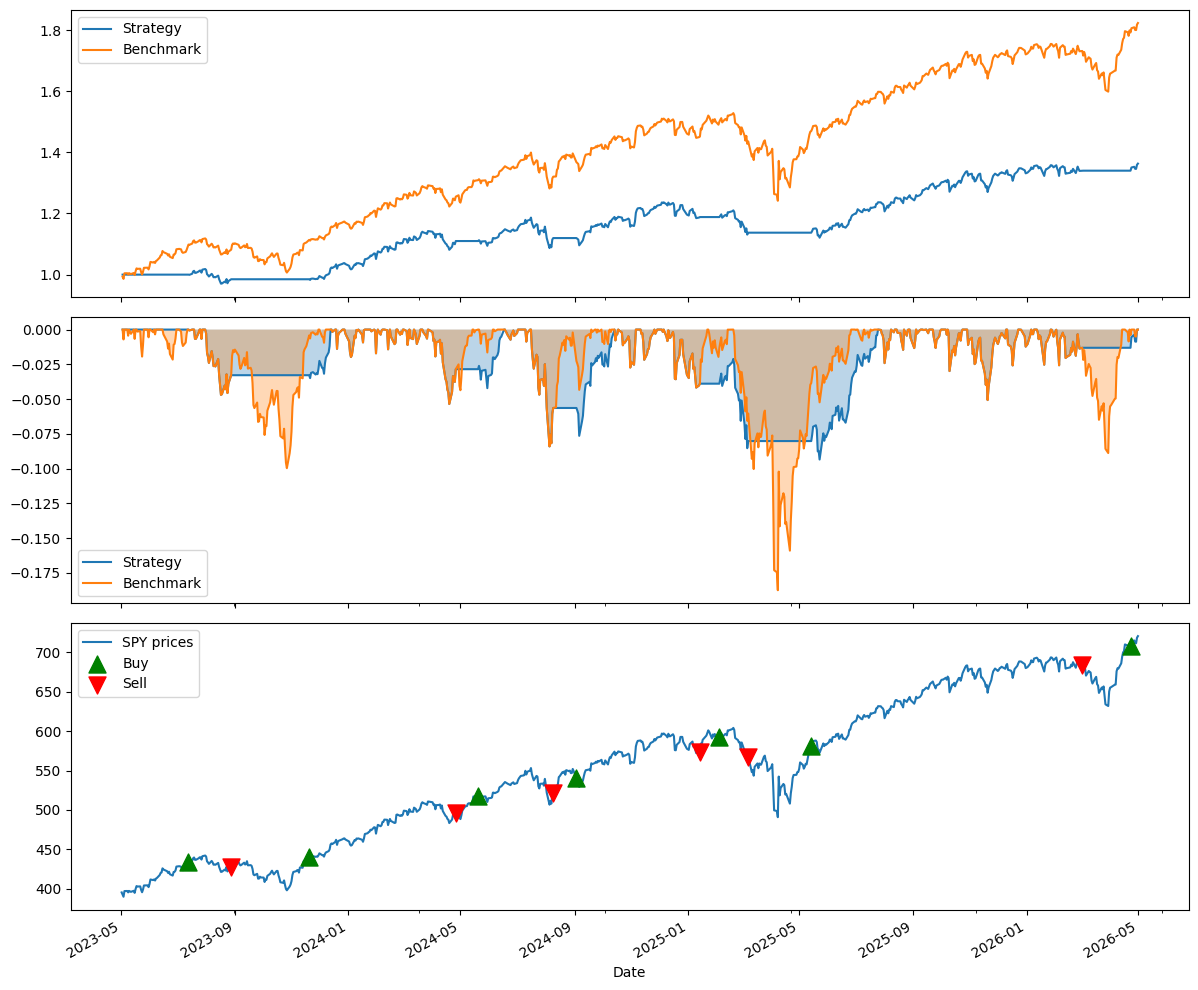

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes = axes.flatten()
strat_returns = results['strategy_returns']
bench_returns = results['benchmark_returns']
signals = results['signals']

# Plot 1 — Equity curves
strat_wealth = np.exp(np.cumsum(strat_returns / 100))
bench_wealth = np.exp(np.cumsum(bench_returns / 100))
# plot both on axes[0]
strat_wealth.plot(ax=axes[0], label='Strategy')
bench_wealth.plot(ax=axes[0], label='Benchmark')
axes[0].legend()

# Plot 2 — Drawdown
# compute drawdown series for both using the wealth index
# plot both on axes[1], fill below zero with fill_between

strat_peaks = np.maximum.accumulate(strat_wealth)
strat_drawdowns = (strat_wealth - strat_peaks) / strat_peaks

bench_peaks = np.maximum.accumulate(bench_wealth)
bench_drawdowns = (bench_wealth - bench_peaks) / bench_peaks

strat_drawdowns.plot(ax=axes[1], label='Strategy')
axes[1].fill_between(strat_drawdowns.index, strat_drawdowns.values, where=(strat_drawdowns<0), alpha=0.3)

bench_drawdowns.plot(ax=axes[1], label='Benchmark')
axes[1].fill_between(bench_drawdowns.index, bench_drawdowns.values, where=(bench_drawdowns<0), alpha=0.3)
axes[1].legend()

# Plot 3 — Price with signals
# plot prices on axes[2]
# overlay buy signals as green markers
# overlay sell signals as red markers
# hint: buy happens when signal changes from 0 to 1
#       sell happens when signal changes from 1 to 0

signal_changes = signals.diff()
buy_dates = signal_changes[signal_changes == 1].index
sell_dates = signal_changes[signal_changes == -1].index

prices.plot(ax=axes[2], label='SPY prices')
axes[2].scatter(buy_dates, prices[buy_dates], marker='^', color='green', s=150, zorder=5, label='Buy')
axes[2].scatter(sell_dates, prices[sell_dates], marker='v', color='red', s=150, zorder=5, label='Sell')
axes[2].legend()

plt.tight_layout()